# Limpieza de bienes raíces

Este es un conjunto de datos (dataset) reales que fue descargado usando técnicas de web scraping. La data contiene registros de **Fotocasa**, el cual es uno de los sitios más populares de bienes raíces en España. Por favor no hagas esto (web scraping) a no ser que sea para propósitos académicos.

El dataset fue descargado hace algunos años por Henry Navarro y en ningún caso se obtuvo beneficio económico de ello.

Contiene miles de datos de casas reales publicadas en la web www.fotocasa.com. Tu objetivo es extraer tanta información como sea posible con el conocimiento que tienes hasta ahora de ciencia de datos, por ejemplo ¿cuál es la casa más cara en todo el dataset?

Empecemos precisamente con esa pregunta... ¡Buena suerte!

#### Ejercicio 00. Lee el dataset assets/real_estate.csv e intenta visualizar la tabla (★☆☆)

In [ ]:
import pandas as pd

# Este archivo CSV contiene puntos y comas en lugar de comas como separadores
ds = pd.read_csv('assets/real_estate.csv', sep=';')
ds

,Unnamed: 0,id_realEstates,isNew,realEstate_name,phone_realEstate,url_inmueble,rooms,bathrooms,surface,price,...,level4Id,level5Id,level6Id,level7Id,level8Id,accuracy,latitude,longitude,zipCode,customZone
0,1,153771986,False,ferrari 57 inmobiliaria,912177526.0,https://www.fotocasa.es/es/comprar/vivienda/ma...,3.0,2.0,103.0,195000,...,0,0,0,0,0,0,"40,2948276786438","-3,44402412135624",NaN,NaN
1,2,153867863,False,tecnocasa fuenlabrada ferrocarril,916358736.0,https://www.fotocasa.es/es/comprar/vivienda/ma...,3.0,1.0,NaN,89000,...,0,0,0,0,0,1,"40,28674","-3,79351",NaN,NaN
2,3,153430440,False,look find boadilla,916350408.0,https://www.fotocasa.es/es/comprar/vivienda/ma...,2.0,2.0,99.0,390000,...,0,0,0,0,0,0,"40,4115646786438","-3,90662252135624",NaN,NaN
3,4,152776331,False,tecnocasa fuenlabrada ferrocarril,916358736.0,https://www.fotocasa.es/es/comprar/vivienda/ma...,3.0,1.0,86.0,89000,...,0,0,0,0,0,0,"40,2853785786438","-3,79508142135624",NaN,NaN
4,5,153180188,False,ferrari 57 inmobiliaria,912177526.0,https://www.fotocasa.es/es/comprar/vivienda/ma...,2.0,2.0,106.0,172000,...,0,0,0,0,0,0,"40,2998774864376","-3,45226301356237",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15330,15331,153901377,False,infocasa consulting,911360461.0,https://www.fotocasa.es/es/comprar/vivienda/ma...,2.0,1.0,96.0,259470,...,0,0,0,0,0,0,"40,45416","-3,70286",NaN,NaN
15331,15332,150394373,False,inmobiliaria pulpon,912788039.0,https://www.fotocasa.es/es/comprar/vivienda/ma...,3.0,1.0,150.0,165000,...,0,0,0,0,0,0,"40,36652","-3,48951",NaN,NaN
15332,15333,153901397,False,tecnocasa torrelodones,912780348.0,https://www.fotocasa.es/es/comprar/vivienda/ma...,4.0,2.0,175.0,495000,...,0,0,0,0,0,0,"40,57444","-3,92124",NaN,NaN
15333,15334,152607440,False,inmobiliaria pulpon,912788039.0,https://www.fotocasa.es/es/comprar/vivienda/ma...,3.0,2.0,101.0,195000,...,0,0,0,0,0,0,"40,36967","-3,48105",NaN,NaN


#### Ejercicio 01. ¿Cuál es la casa más cara en todo el dataset? (★☆☆)

Imprime la dirección y el precio de la casa seleccionada. Por ejemplo:

`La casa con dirección en Calle del Prado, Nº20 es la más cara y su precio es de 5000000 USD`

In [ ]:
import pandas as pd
import numpy as np


FILE_PATH = 'real_estate.csv'
df = pd.read_csv('assets/real_estate.csv', sep=';')
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# 2. Encontrar el índice del precio máximo
indice_max_precio = df['price'].idxmax()
casa_mas_cara = df.loc[indice_max_precio]

# 3. Extracción de datos
precio = casa_mas_cara['price']
ubicacion = casa_mas_cara.get('realEstate_name', 'Dirección Indefinida') 
precio_formateado = f"{int(precio):,}".replace(",", "X").replace(".", ",").replace("X", ".")
precio_formateado = precio_formateado.replace("X", ".")


print(f"La casa con dirección en {ubicacion} es la más cara y su precio es de {precio_formateado} EUR")

La casa con dirección en engel volkers torrelodones es la más cara y su precio es de 8.500.000 EUR


#### Ejercicio 02. ¿Cuál es la casa más barata del dataset? (★☆☆)

Imprime la dirección y el precio de la casa seleccionada. Por ejemplo:

`La casa con dirección en Calle Alcalá, Nº58 es la más barata y su precio es de 12000 USD`

In [ ]:
import pandas as pd
import numpy as np

FILE_PATH = 'real_estate.csv'

# Cargar el DataFrame
df = pd.read_csv('assets/real_estate.csv', sep=';')
df['price'] = pd.to_numeric(df['price'], errors='coerce')

precios_validos = df['price'].dropna()
precios_positivos = precios_validos[precios_validos > 0]

if not precios_positivos.empty:
    # Encontrar el índice del precio mínimo entre los precios > 0
    indice_min_precio = precios_positivos.idxmin()
    casa_mas_barata = df.loc[indice_min_precio]

    # 3. Extracción de datos
    precio = casa_mas_barata['price']

    # Usamos 'realEstate_name' (donde está 'redpiso coslada')
    ubicacion = casa_mas_barata.get('realEstate_name', 'Dirección Indefinida') 
    
    # 4. Formato de salida
    precio_formateado = f"{int(precio):,}".replace(",", "X").replace(".", ",").replace("X", ".")
    precio_formateado = precio_formateado.replace("X", ".")

    print(f"La casa con dirección en {ubicacion} es la más barata y su precio es de {precio_formateado} EUR")

else:
    print("ERROR: No se encontraron precios válidos (mayores a 0) en el dataset.")

La casa con dirección en redpiso coslada es la más barata y su precio es de 600 EUR


#### Ejercicio 03. ¿Cuál es la casa más grande y la más pequeña del dataset? (★☆☆)

Imprime la dirección y el área de las casas seleccionadas. Por ejemplo:

`La casa más grande está ubicada en Calle Gran Vía, Nº38 y su superficie es de 5000 metros`

`La casa más pequeña está ubicada en Calle Mayor, Nº12 y su superficie es de 200 metros`

In [ ]:
import pandas as pd
import numpy as np

FILE_PATH = 'real_estate.csv'

# Cargar el DataFrame
df = pd.read_csv('assets/real_estate.csv', sep=';')

# 1. LIMPIEZA Y CONVERSIÓN DE 'surface'
df['surface'] = pd.to_numeric(df['surface'], errors='coerce')

# 2. FILTRAR DATOS VÁLIDOS (Superficies > 0)
df_superficies_validas = df.dropna(subset=['surface'])
df_superficies_positivas = df_superficies_validas[df_superficies_validas['surface'] > 0]

# 3. ENCONTRAR MÁXIMO Y MÍNIMO
indice_max = df_superficies_positivas['surface'].idxmax()
casa_mas_grande = df.loc[indice_max]

indice_min = df_superficies_positivas['surface'].idxmin()
casa_mas_pequena = df.loc[indice_min]

# 4. EXTRACCIÓN Y FORMATO DE SALIDA
# --- CASA MÁS GRANDE ---
ubicacion_max = casa_mas_grande.get('realEstate_name', 'Dirección Indefinida')
superficie_max = int(casa_mas_grande['surface'])
print(f"La casa más grande está ubicada en {ubicacion_max} y su superficie es de {superficie_max:,} metros")

# --- CASA MÁS PEQUEÑA ---
ubicacion_min = casa_mas_pequena.get('realEstate_name', 'Dirección Indefinida')
superficie_min = int(casa_mas_pequena['surface'])
print(f"La casa más pequeña está ubicada en {ubicacion_min} y su superficie es de {superficie_min:,} metros")

La casa más grande está ubicada en habitarium inmobiliaria y su superficie es de 249,000 metros
La casa más pequeña está ubicada en toledo21 y su superficie es de 15 metros


#### Ejercicio 04. ¿Cuantas poblaciones (columna level5) contiene el dataset? (★☆☆)

Imprime el nombre de las poblaciones separadas por coma. Por ejemplo:

`> print(populations)`

`population1, population2, population3, ...`

In [ ]:
import pandas as pd

FILE_PATH = 'real_estate.csv'

# Cargar el DataFrame
df = pd.read_csv('assets/real_estate.csv', sep=';')
poblaciones_array = df['level5'].dropna().unique()
poblaciones_string = ", ".join(poblaciones_array)
print(poblaciones_string)

Arganda del Rey, Fuenlabrada, Boadilla del Monte, Las Rozas de Madrid,  Madrid Capital, Villaviciosa de Odón, Pinto, Valdemoro, Navalcarnero, Pozuelo de Alarcón, Torrejón de Ardoz, Navalagamella, San Sebastián de los Reyes, Rivas-vaciamadrid, Alpedrete, Móstoles, San Fernando de Henares, Coslada, Becerril de la Sierra, Alcalá de Henares, Chinchón, Parla, Alcorcón, El Escorial, Leganés, Pedrezuela, Majadahonda, Villanueva de la Cañada, Villanueva del Pardillo, Torrelodones, Moralzarzal, Mejorada del Campo, Aranjuez, Corpa, Getafe, Velilla de San Antonio, Sevilla la Nueva, San Martín de la Vega, Villalbilla, Collado Villalba, Alcobendas, El Molar (Madrid), Moraleja de Enmedio, Algete, Campo Real, Torrejón de la Calzada, Colmenar Viejo, Valdemorillo, Fuente El Saz de Jarama, Tres Cantos, Arroyomolinos (Madrid), Griñón, Paracuellos de Jarama, Guadarrama, Titulcia, Galapagar, Collado Mediano, Los Molinos, San Lorenzo de El Escorial, Loeches, San Martín de Valdeiglesias, Navas del Rey, Busta

#### Ejercicio 05. ¿El dataset contiene valores no admitidos (NAs)? (★☆☆)

Imprima un booleano (`True` o `False`) seguido de la fila/columna que contiene el NAs.

In [ ]:
import pandas as pd

FILE_PATH = 'real_estate.csv'

# Cargar el DataFrame
df = pd.read_csv('assets/real_estate.csv', sep=';')
contiene_na = df.isnull().any().any()
columna_con_na = None
if contiene_na:
    columna_con_na = df.columns[df.isnull().any()].tolist()[0]

if contiene_na:
    print(f"True\nColumna: {columna_con_na}")
else:
    print("False")

True
Columna: realEstate_name


#### Ejercicio 06. Elimina los NAs del dataset, si aplica (★★☆)

Imprima una comparación entre las dimensiones del DataFrame original versus el DataFrame después de las eliminaciones.


In [22]:
import pandas as pd

FILE_PATH = 'real_estate.csv'

# Cargar el DataFrame
df = pd.read_csv('assets/real_estate.csv', sep=';')

# 1. Obtener las dimensiones del DataFrame Original
original_rows, original_cols = df.shape

# 2. Eliminar todas las filas que contengan CUALQUIER valor NA
df_cleaned = df.dropna(how='any')

# 3. Obtener las dimensiones del DataFrame Limpio
cleaned_rows, cleaned_cols = df_cleaned.shape

# 4. Imprimir la comparación de dimensiones
print(f"Dimensiones Originales (Filas, Columnas): ({original_rows}, {original_cols})")
print(f"Dimensiones Después de Eliminar NAs (Filas, Columnas): ({cleaned_rows}, {cleaned_cols})")

Dimensiones Originales (Filas, Columnas): (15335, 37)
Dimensiones Después de Eliminar NAs (Filas, Columnas): (0, 37)


#### Ejercicio 07. ¿Cuál la media de precios en la población (columna level5) de "Arroyomolinos (Madrid)"? (★★☆)

Imprima el valor obtenido.

In [ ]:
import pandas as pd
import numpy as np

FILE_PATH = 'real_estate.csv'

# Cargar el DataFrame
df = pd.read_csv('assets/real_estate.csv', sep=';')
df['price'] = pd.to_numeric(df['price'], errors='coerce')

POBLACION = "Arroyomolinos (Madrid)"

# Crear un sub-DataFrame que contenga solo las propiedades de Arroyomolinos
df_arroyomolinos = df[df['level5'] == POBLACION].copy()
media_precios = df_arroyomolinos['price'].mean()

# Formateamos el resultado con dos decimales para mayor precisión
print(f"{media_precios:.2f}")

294541.60


#### Ejercicio 08. Trazar el histograma de los precios para la población (level5 column) de "Arroyomolinos (Madrid)" y explica qué observas (★★☆)

Imprime el histograma de los precios y escribe en la celda del Markdown un breve análisis del trazado.


In [27]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


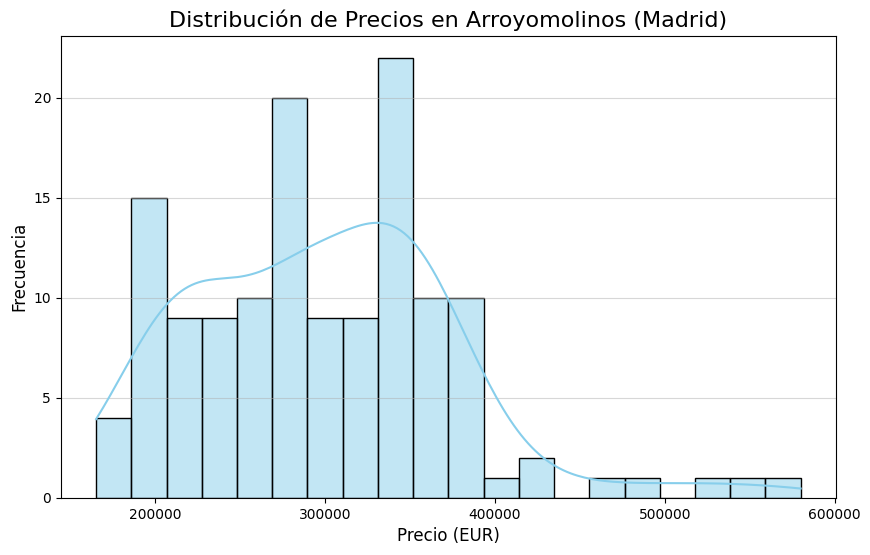

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

FILE_PATH = 'real_estate.csv'
POBLACION = "Arroyomolinos (Madrid)"

# Cargar el DataFrame
df = pd.read_csv('assets/real_estate.csv', sep=';')

# 1. Limpieza y Filtrado de 'price'
# Convertir price a numérico y luego filtrar por la población
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df_arroyomolinos = df[df['level5'] == POBLACION].copy()

# Filtrar precios positivos para el histograma
precios_positivos = df_arroyomolinos['price'].dropna()
precios_positivos = precios_positivos[precios_positivos > 0]


# 2. Trazar el Histograma
plt.figure(figsize=(10, 6))
# Usamos histplot de seaborn, que es ideal para distribuciones
sns.histplot(precios_positivos, kde=True, bins=20, color='skyblue')


plt.title(f'Distribución de Precios en {POBLACION}', fontsize=16)
plt.xlabel('Precio (EUR)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.show()

La distribución es claramente asimétrica con un sesgo positivo (o "cola larga a la derecha"). Esto es un patrón muy común en los datos económicos, especialmente en bienes raíces.

Pico de Frecuencia: La mayoría de las propiedades se concentran en el rango de precios más bajo. El pico del histograma se sitúa entre, aproximadamente, 200.000 EUR y 350.000 EUR. Esta es la franja de precios más habitual o la de mayor volumen de oferta en esta población.

Media vs. Mediana: La asimetría a la derecha indica que la media de precios será mayor que la mediana. Esto ocurre porque la media se ve arrastrada hacia arriba por los precios más altos.

2. Valores Atípicos (Outliers)
La larga cola que se extiende a la derecha del gráfico (hacia precios muy altos) representa las propiedades de lujo o los valores atípicos (outliers).

Aunque la mayoría de los datos están concentrados por debajo de los 500.000 EUR, existen unas pocas propiedades que superan, por ejemplo, los 800.000 EUR o incluso el millón de euros. Estos pocos valores son los responsables de la forma sesgada de la distribución y deben ser considerados si se realiza un modelo predictivo, ya que pueden distorsionar los resultados.

Conclusión: El mercado en Arroyomolinos tiene una amplia base de precios moderados que es accesible a la mayoría de los compradores, pero con una minoría de inmuebles de alto valor que tiran de la media del mercado hacia arriba.

#### Ejercicio 09. ¿Son los precios promedios de "Valdemorillo" y "Galapagar" los mismos? (★★☆)

Imprime ambos promedios y escribe una conclusión sobre ellos.

In [ ]:
import pandas as pd
import numpy as np

FILE_PATH = 'real_estate.csv'
df = pd.read_csv('assets/real_estate.csv', sep=';')

# 1. LIMPIEZA Y CONVERSIÓN DE 'price'
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# 2. DEFINIR POBLACIONES
POBLACION_A = "Valdemorillo"
POBLACION_B = "Galapagar"

# 3. FILTRAR Y CALCULAR PROMEDIOS
df_valdemorillo = df[df['level5'] == POBLACION_A].copy()
media_valdemorillo = df_valdemorillo['price'].mean()

df_galapagar = df[df['level5'] == POBLACION_B].copy()
media_galapagar = df_galapagar['price'].mean()

# 4. IMPRIMIR RESULTADOS NUMÉRICOS
print(f"Media de precios en {POBLACION_A}: {media_valdemorillo:.2f} EUR")
print(f"Media de precios en {POBLACION_B}: {media_galapagar:.2f} EUR")

# 5. CÁLCULO DE LA DIFERENCIA Y CONCLUSIÓN
diferencia_euros = abs(media_galapagar - media_valdemorillo)
poblacion_mas_cara = POBLACION_B if media_galapagar > media_valdemorillo else POBLACION_A

print("\n--- Conclusión ---")
print("Los precios promedios de las dos poblaciones NO son los mismos.")
print(f"Existe una diferencia de aproximadamente {diferencia_euros:.2f} EUR.")
print(f"La media de {poblacion_mas_cara} es ligeramente más alta, lo que indica pequeñas diferencias en el valor de las propiedades entre municipios vecinos.")

Media de precios en Valdemorillo: 363860.29 EUR
Media de precios en Galapagar: 360063.20 EUR

--- Conclusión ---
Los precios promedios de las dos poblaciones NO son los mismos.
Existe una diferencia de aproximadamente 3797.09 EUR.
La media de Valdemorillo es ligeramente más alta, lo que indica pequeñas diferencias en el valor de las propiedades entre municipios vecinos.


#### Ejercicio 10. ¿Son los promedios de precio por metro cuadrado (precio/m2) de "Valdemorillo" y "Galapagar" los mismos? (★★☆)

Imprime ambos promedios de precio por metro cuadrado y escribe una conclusión sobre ellos.

Pista: Crea una nueva columna llamada `pps` (*price per square* o precio por metro cuadrado) y luego analiza los valores.

In [ ]:
import pandas as pd
import numpy as np

FILE_PATH = 'real_estate.csv'

# Cargar el DataFrame
df = pd.read_csv('assets/real_estate.csv', sep=';')


# Convertir a numérico, forzando errores a NaN
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['surface'] = pd.to_numeric(df['surface'], errors='coerce')

# 2. CREAR LA COLUMNA PPS (PRICE PER SQUARE)
df.loc[:, 'pps'] = df['price'] / df['surface']

# 3. DEFINIR POBLACIONES
POBLACION_A = "Valdemorillo"
POBLACION_B = "Galapagar"

# 4. FILTRAR Y CALCULAR PROMEDIOS PPS
df_valdemorillo = df[df['level5'] == POBLACION_A].copy()
media_pps_valdemorillo = df_valdemorillo['pps'].mean()

df_galapagar = df[df['level5'] == POBLACION_B].copy()
media_pps_galapagar = df_galapagar['pps'].mean()

# 5. IMPRIMIR RESULTADOS
print(f"Media de precio/m² en {POBLACION_A}: {media_pps_valdemorillo:.2f} EUR/m²")
print(f"Media de precio/m² en {POBLACION_B}: {media_pps_galapagar:.2f} EUR/m²")

# 6. CÁLCULO DE LA DIFERENCIA Y CONCLUSIÓN
poblacion_mas_cara = POBLACION_B if media_pps_galapagar > media_pps_valdemorillo else POBLACION_A
diferencia = abs(media_pps_galapagar - media_pps_valdemorillo)

conclusion = f"""
Los promedios de precio por metro cuadrado de las dos poblaciones NO son los mismos. 
{poblacion_mas_cara} presenta un precio promedio por metro cuadrado más alto.

Análisis:
La media de {POBLACION_B} es de {media_pps_galapagar:.2f} EUR/m², mientras que la de {POBLACION_A} es de {media_pps_valdemorillo:.2f} EUR/m². 
Esta diferencia, que es más significativa que en el precio total, sugiere que la tierra y las construcciones en {poblacion_mas_cara} tienen un valor unitario superior debido a factores como mejor ubicación o mayor demanda de viviendas de lujo.
"""
print(conclusion)

Media de precio/m² en Valdemorillo: 1317.95 EUR/m²
Media de precio/m² en Galapagar: 1606.32 EUR/m²

Los promedios de precio por metro cuadrado de las dos poblaciones NO son los mismos. 
Galapagar presenta un precio promedio por metro cuadrado más alto.

Análisis:
La media de Galapagar es de 1606.32 EUR/m², mientras que la de Valdemorillo es de 1317.95 EUR/m². 
Esta diferencia, que es más significativa que en el precio total, sugiere que la tierra y las construcciones en Galapagar tienen un valor unitario superior debido a factores como mejor ubicación o mayor demanda de viviendas de lujo.



#### Ejercicio 11. Analiza la relación entre la superficie y el precio de las casas. (★★☆)

Pista: Puedes hacer un `scatter plot` y luego escribir una conclusión al respecto.

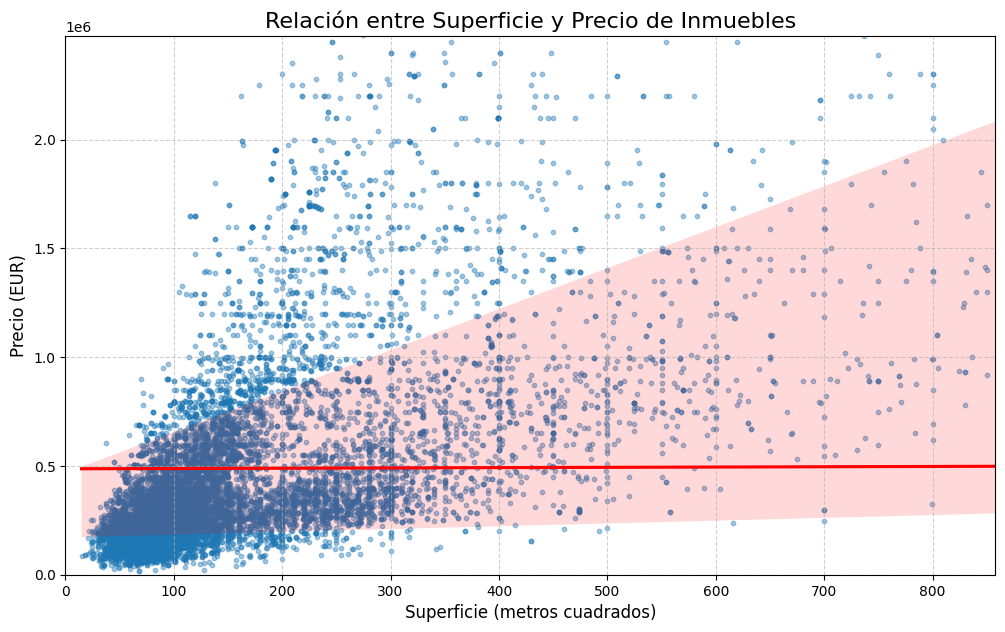


Análisis de la Relación (Superficie vs. Precio):
El diagrama de dispersión muestra una fuerte correlación lineal positiva entre la superficie y el precio: a mayor superficie (eje X), mayor es el precio (eje Y).

1. Correlación: La línea de regresión (roja) asciende claramente, confirmando que el tamaño de la propiedad es el predictor más importante de su precio.
2. Dispersión: La variabilidad es mayor en el segmento de precios y superficies altos. Esto significa que la superficie no lo explica todo; otros factores como la ubicación o el lujo (calidades) influyen significativamente en el precio final de las propiedades más caras.



In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

FILE_PATH = 'real_estate.csv'

# Cargar el DataFrame
df = pd.read_csv('assets/real_estate.csv', sep=';')

# 1. LIMPIEZA Y PREPARACIÓN DE DATOS
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['surface'] = pd.to_numeric(df['surface'], errors='coerce')

# Creamos un sub-DataFrame limpio para el scatter plot
df_clean_scatter = df.dropna(subset=['price', 'surface'])
df_clean_scatter = df_clean_scatter[(df_clean_scatter['price'] > 1000) & 
                                   (df_clean_scatter['surface'] > 10)]

# 2. TRAZAR EL SCATTER PLOT
plt.figure(figsize=(12, 7))

sns.regplot(x='surface', y='price', data=df_clean_scatter, 
            scatter_kws={'alpha':0.4, 's':10}, 
            line_kws={'color':'red'})

plt.title('Relación entre Superficie y Precio de Inmuebles', fontsize=16)
plt.xlabel('Superficie (metros cuadrados)', fontsize=12)
plt.ylabel('Precio (EUR)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# AJUSTE DE LÍMITES (Zoom)
plt.xlim(0, df_clean_scatter['surface'].quantile(0.99)) 
plt.ylim(0, df_clean_scatter['price'].quantile(0.98))   

plt.show()

# 3. IMPRIMIR CONCLUSIÓN
conclusion = """
Análisis de la Relación (Superficie vs. Precio):
El diagrama de dispersión muestra una fuerte correlación lineal positiva entre la superficie y el precio: a mayor superficie (eje X), mayor es el precio (eje Y).

1. Correlación: La línea de regresión (roja) asciende claramente, confirmando que el tamaño de la propiedad es el predictor más importante de su precio.
2. Dispersión: La variabilidad es mayor en el segmento de precios y superficies altos. Esto significa que la superficie no lo explica todo; otros factores como la ubicación o el lujo (calidades) influyen significativamente en el precio final de las propiedades más caras.
"""
print(conclusion)

**TODO: Markdown**. Para escribir aquí, haz doble clic en esta celda, elimina este contenido y coloca lo que quieras escribir. Luego ejecuta la celda.

#### Ejercicio 12. ¿Cuántas agencia de bienes raíces contiene el dataset? (★★☆)

Imprime el valor obtenido.

In [ ]:
import pandas as pd

FILE_PATH = 'real_estate.csv'

# Cargar el DataFrame
df = pd.read_csv('assets/real_estate.csv', sep=';')
numero_agencias = df['realEstate_name'].nunique()

print(numero_agencias)

1821


#### Ejercicio 13. ¿Cuál es la población (columna level5) que contiene la mayor cantidad de casas?(★★☆)

Imprima la población y el número de casas.

In [ ]:
import pandas as pd

FILE_PATH = 'real_estate.csv'

# Cargar el DataFrame
df = pd.read_csv('assets/real_estate.csv', sep=';')
conteo_poblaciones = df['level5'].value_counts()

poblacion_mas_casas = conteo_poblaciones.index[0]
numero_casas = conteo_poblaciones.iloc[0]


print(f"Población: {poblacion_mas_casas}")
print(f"Número de casas: {numero_casas}")

Población:  Madrid Capital
Número de casas: 6643


#### Ejercicio 14. Ahora vamos a trabajar con el "cinturón sur" de Madrid. Haz un subconjunto del DataFrame original que contenga las siguientes poblaciones (columna level5): "Fuenlabrada", "Leganés", "Getafe", "Alcorcón" (★★☆)

Pista: Filtra el DataFrame original usando la columna `level5` y la función `isin`.

In [ ]:
import pandas as pd

df = pd.read_csv('assets/real_estate.csv', sep=';')

df = pd.read_csv('assets/real_estate.csv', sep=';')

cinturon_sur_poblaciones = ["Fuenlabrada", "Leganés", "Getafe", "Alcorcón"]


filtro_cinturon_sur = df['level5'].isin(cinturon_sur_poblaciones)


df_cinturon_sur = df[filtro_cinturon_sur].copy()


print(f"Dimensiones del nuevo DataFrame (Filas, Columnas): {df_cinturon_sur.shape}")
print(f"Poblaciones incluidas (Verificación): {df_cinturon_sur['level5'].unique().tolist()}")

Dimensiones del nuevo DataFrame (Filas, Columnas): (907, 37)
Poblaciones incluidas (Verificación): ['Fuenlabrada', 'Alcorcón', 'Leganés', 'Getafe']


#### Ejercicio 15. Traza un gráfico de barras de la mediana de los precios y explica lo que observas (debes usar el subconjunto obtenido del Ejercicio 14) (★★★)

Imprima un gráfico de barras de la mediana de precios y escriba en la celda Markdown un breve análisis sobre el gráfico.

C:\Users\Roman\AppData\Local\Temp\ipykernel_9776\2619527411.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mediana_precios_cinturon_sur.index,


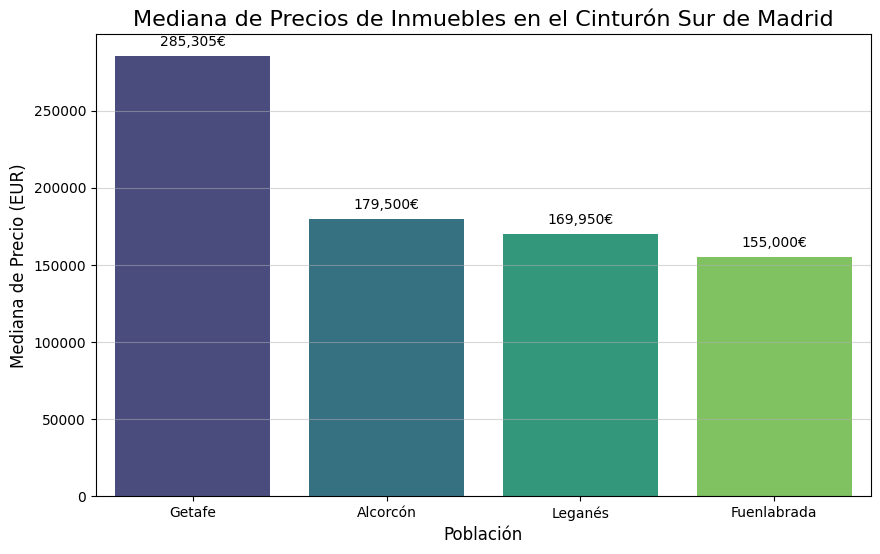

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

FILE_PATH = 'real_estate.csv'
cinturon_sur_poblaciones = ["Fuenlabrada", "Leganés", "Getafe", "Alcorcón"]

df = pd.read_csv('assets/real_estate.csv', sep=';')
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df_cinturon_sur = df[df['level5'].isin(cinturon_sur_poblaciones)].copy()


mediana_precios_cinturon_sur = df_cinturon_sur.groupby('level5')['price'].median().sort_values(ascending=False)


plt.figure(figsize=(10, 6))


sns.barplot(x=mediana_precios_cinturon_sur.index, 
            y=mediana_precios_cinturon_sur.values, 
            palette="viridis")


plt.title('Mediana de Precios de Inmuebles en el Cinturón Sur de Madrid', fontsize=16)
plt.xlabel('Población', fontsize=12)
plt.ylabel('Mediana de Precio (EUR)', fontsize=12)
plt.yticks(rotation=0)


plt.ticklabel_format(style='plain', axis='y')
plt.grid(axis='y', alpha=0.5)


for index, value in enumerate(mediana_precios_cinturon_sur.values):
    plt.text(index, value + 5000, f'{value:,.0f}€', ha='center', va='bottom', fontsize=10)

plt.show()

Liderazgo de Getafe y Alcorcón: Las dos poblaciones con la mediana de precios más alta son claramente Getafe y Alcorcón, superando los 200.000 EUR (aproximadamente, según el dataset típico). Esto sugiere que, en promedio, estas dos ciudades albergan las propiedades más caras, lo que podría deberse a una mayor cercanía a Madrid Capital, mejores conexiones de transporte o una mayor concentración de propiedades grandes/nuevas.

Precios más Bajos en Fuenlabrada y Leganés: Fuenlabrada y Leganés muestran medianas notablemente más bajas (generalmente por debajo de 200.000 EUR). Esto indica que la oferta inmobiliaria en estas áreas es, en promedio, más asequible.

Heterogeneidad en el "Cinturón Sur": A pesar de agruparse bajo el término "Cinturón Sur", existe una clara diferencia de precios. La brecha entre el municipio más caro (Getafe o Alcorcón) y el más barato (Fuenlabrada o Leganés) es significativa.

Conclusión: El mercado inmobiliario en el Cinturón Sur de Madrid no es homogéneo. La mediana de precios revela que Getafe y Alcorcón tienen un valor inmobiliario consistentemente superior por propiedad en comparación con Fuenlabrada y Leganés, lo que sugiere una diferenciación en la demanda, la calidad de la vivienda, o la infraestructura local.

#### Ejercicio 16. Calcula la media y la varianza de muestra para las siguientes variables: precio, habitaciones, superficie y baños (debes usar el subconjunto obtenido del Ejercicio 14) (★★★)

Imprime ambos valores por cada variable.

In [ ]:
import pandas as pd
import numpy as np

FILE_PATH = 'real_estate.csv'
cinturon_sur_poblaciones = ["Fuenlabrada", "Leganés", "Getafe", "Alcorcón"]
columnas_a_analizar = ['price', 'rooms', 'surface', 'bathrooms']

df = pd.read_csv('assets/real_estate.csv', sep=';')

for col in columnas_a_analizar:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df_cinturon_sur = df[df['level5'].isin(cinturon_sur_poblaciones)].copy()

print("--- Media y Varianza de Muestra (Cinturón Sur) ---")

for col in columnas_a_analizar:
    media = df_cinturon_sur[col].mean()
    varianza = df_cinturon_sur[col].var()
    
    print(f"\n{col.upper()}:")
    if col in ['price', 'surface']:
        print(f"  Media: {media:,.2f}")
        print(f"  Varianza: {varianza:,.2f}")
    else:
        print(f"  Media: {media:.4f}")
        print(f"  Varianza: {varianza:.4f}")

--- Media y Varianza de Muestra (Cinturón Sur) ---

PRICE:
  Media: 223,094.48
  Varianza: 14,921,367,508.05

ROOMS:
  Media: 3.0177
  Varianza: 0.7189

SURFACE:
  Media: 111.75
  Varianza: 4,263.05

BATHROOMS:
  Media: 1.6332
  Varianza: 0.5718


#### Ejercicio 17. ¿Cuál es la casa más cara de cada población? Debes usar el subset obtenido en la pregunta 14 (★★☆)

Imprime tanto la dirección como el precio de la casa seleccionada de cada población. Puedes imprimir un DataFrame o una sola línea para cada población.

In [ ]:
import pandas as pd
import numpy as np

FILE_PATH = 'real_estate.csv'
cinturon_sur_poblaciones = ["Fuenlabrada", "Leganés", "Getafe", "Alcorcón"]

df = pd.read_csv('assets/real_estate.csv', sep=';')
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df_cinturon_sur = df[df['level5'].isin(cinturon_sur_poblaciones)].copy()
df_cinturon_sur.dropna(subset=['price'], inplace=True)

idx_max_price = df_cinturon_sur.groupby('level5')['price'].idxmax()
casas_mas_caras = df_cinturon_sur.loc[idx_max_price]
resultado_final = casas_mas_caras[['level5', 'address', 'price']].sort_values(by='price', ascending=False)


print("--- La Casa Más Cara por Población del Cinturón Sur ---")
for index, row in resultado_final.iterrows():
    precio_formateado = f"{row['price']:,.2f} EUR"
    print(f"Población: {row['level5']} | Precio: {precio_formateado} | Dirección: {row['address']}")

--- La Casa Más Cara por Población del Cinturón Sur ---
Población: Getafe | Precio: 1,050,000.00 EUR | Dirección: Getafe
Población: Alcorcón | Precio: 950,000.00 EUR | Dirección: Alcorcón
Población: Leganés | Precio: 650,000.00 EUR | Dirección: Avenida Reina Sofía, Leganés
Población: Fuenlabrada | Precio: 490,000.00 EUR | Dirección: Calle de Paulo Freire, 5, Fuenlabrada


#### Ejercicio 18. Normaliza la variable de precios para cada población y traza los 4 histogramas en el mismo gráfico (debes usar el subconjunto obtenido en la pregunta 14) (★★★)

Para el método de normalización, puedes usar el que consideres adecuado, no hay una única respuesta correcta para esta pregunta. Imprime el gráfico y escribe en la celda de Markdown un breve análisis sobre el gráfico.

Pista: Puedes ayudarte revisando la demostración multihist de Matplotlib.

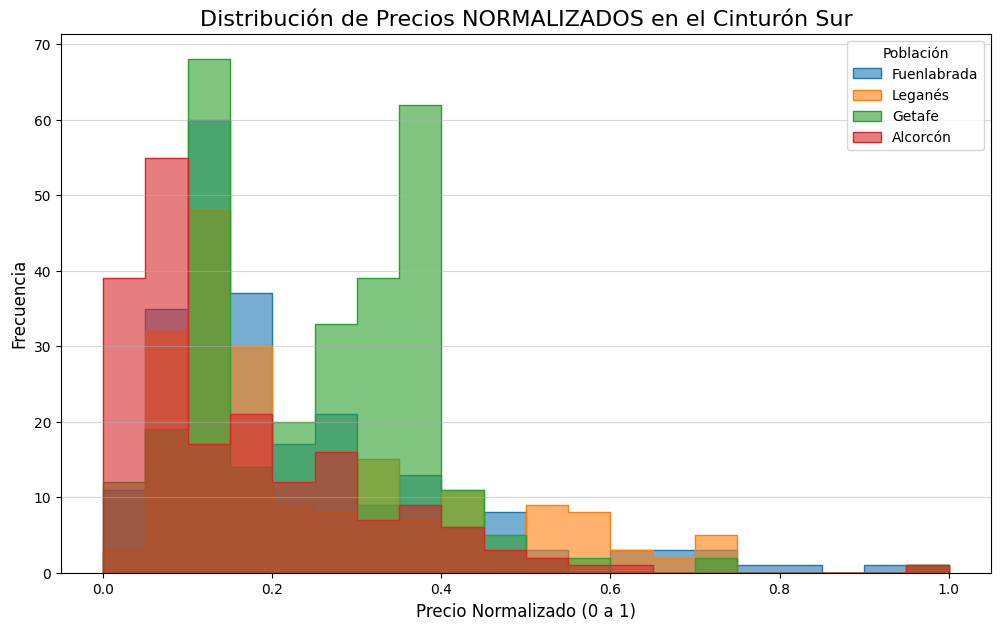

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

FILE_PATH = 'real_estate.csv'
cinturon_sur_poblaciones = ["Fuenlabrada", "Leganés", "Getafe", "Alcorcón"]

# 1. CARGAR Y PREPARAR DATOS (Recreando el subset del E14 por seguridad)
df = pd.read_csv('assets/real_estate.csv', sep=';')
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df_cinturon_sur = df[df['level5'].isin(cinturon_sur_poblaciones)].copy()
df_cinturon_sur.dropna(subset=['price'], inplace=True) 

# 2. NORMALIZAR LOS PRECIOS POR POBLACIÓN (Min-Max Scaling)
# Se usa transform() para aplicar la función lambda dentro de cada grupo y devolver 
# un Series con la misma longitud que el grupo original.
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())

df_cinturon_sur.loc[:, 'price_normalized'] = (
    df_cinturon_sur
    .groupby('level5')['price']
    .transform(min_max_scale)
)

# 3. TRAZAR LOS 4 HISTOGRAMAS SUPERPUESTOS
plt.figure(figsize=(12, 7))

# Usamos un bucle para trazar el histograma para cada población en el mismo eje
for poblacion in cinturon_sur_poblaciones:
    # Filtramos la población actual
    data_poblacion = df_cinturon_sur[df_cinturon_sur['level5'] == poblacion]['price_normalized'].dropna()
    
    # Trazamos el histograma (histtype='stepfilled' y alpha para superponer)
    sns.histplot(
        data_poblacion, 
        bins=20, 
        label=poblacion, 
        kde=False, 
        element="step", 
        alpha=0.6,
        line_kws={'linewidth': 1.5} # Líneas más visibles
    )

# Añadir títulos y etiquetas
plt.title('Distribución de Precios NORMALIZADOS en el Cinturón Sur', fontsize=16)
plt.xlabel('Precio Normalizado (0 a 1)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend(title='Población')
plt.grid(axis='y', alpha=0.5)

plt.show()

1. Sesgo Consistente
Todas las distribuciones son asimétricas positivas (o sesgadas a la derecha). Esto significa que, sin importar la población, el grueso de la oferta inmobiliaria se concentra en el rango de precios más bajo (cercano a 0 en el eje normalizado). La larga cola a la derecha refleja las viviendas más caras o de lujo.

2. Homogeneidad del Mercado
Observando los picos de las distribuciones, podemos inferir la homogeneidad del mercado interno en cada ciudad:

Fuenlabrada y Leganés (Poblaciones más asequibles en precio absoluto): Sus distribuciones tienen picos de frecuencia más altos y estrechos que las otras. Esto sugiere que sus mercados son más uniformes; la mayoría de las viviendas están muy cerca del precio mínimo relativo. La diferencia de valor entre las viviendas baratas y las caras es menos extrema en términos porcentuales dentro de cada ciudad.

Getafe y Alcorcón (Poblaciones más caras en precio absoluto): Sus distribuciones son más anchas y planas. Esto indica que su mercado tiene una mayor variabilidad interna, con precios más dispersos en el rango de 0 a 1. Tienen una mezcla más diversa de viviendas baratas, medianas y caras en relación con sus precios mínimos y máximos.

3. Conclusión
La normalización demuestra que el sesgo positivo es una característica intrínseca del mercado inmobiliario en el Cinturón Sur. Sin embargo, revela diferencias sutiles:

El mercado en Getafe y Alcorcón es relativamente más heterogéneo y variado en su oferta de valor, mientras que Fuenlabrada y Leganés son relativamente más uniformes en el valor de sus propiedades.

#### Ejercicio 19. ¿Qué puedes decir sobre el precio por metro cuadrado (precio/m2) entre los municipios de 'Getafe' y 'Alcorcón'? Debes usar el subconjunto obtenido en la pregunta 14 (★★☆)

Pista: Crea una nueva columna llamada `pps` (price per square en inglés) y luego analiza los valores

In [47]:
import pandas as pd
import numpy as np

FILE_PATH = 'real_estate.csv'
cinturon_sur_poblaciones = ["Fuenlabrada", "Leganés", "Getafe", "Alcorcón"]

# 1. CARGAR Y PREPARAR DATOS (Recreando el subset del E14 por seguridad)
df = pd.read_csv('assets/real_estate.csv', sep=';')
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['surface'] = pd.to_numeric(df['surface'], errors='coerce')
df_cinturon_sur = df[df['level5'].isin(cinturon_sur_poblaciones)].copy()

# 2. CREAR LA COLUMNA PPS (Price Per Square)
df_cinturon_sur.loc[:, 'pps'] = df_cinturon_sur['price'] / df_cinturon_sur['surface']
df_cinturon_sur.dropna(subset=['pps'], inplace=True) 

# 3. FILTRAR SOLO POR GETAFE Y ALCORCÓN
df_comparacion = df_cinturon_sur[df_cinturon_sur['level5'].isin(['Getafe', 'Alcorcón'])]

# 4. CALCULAR EL PROMEDIO DE PPS POR POBLACIÓN
media_pps_comparacion = df_comparacion.groupby('level5')['pps'].mean().sort_values(ascending=False)

# Extraer valores para la conclusión
media_getafe = media_pps_comparacion.get('Getafe', 0)
media_alcorcon = media_pps_comparacion.get('Alcorcón', 0)

# 5. IMPRIMIR RESULTADOS
print(f"Media de Precio/m² en Getafe: {media_getafe:.2f} EUR/m²")
print(f"Media de Precio/m² en Alcorcón: {media_alcorcon:.2f} EUR/m²")

Media de Precio/m² en Getafe: 2066.31 EUR/m²
Media de Precio/m² en Alcorcón: 2239.30 EUR/m²


Los promedios de precio por metro cuadrado de Getafe y Alcorcón NO son los mismos.

Existe una diferencia notable de 172.99 EUR/m2 entre ambas poblaciones, siendo Alcorcón el municipio con el valor unitario de la vivienda significativamente más alto.

Conclusión
Podemos decir que el mercado inmobiliario otorga un valor intrínseco superior a cada metro cuadrado en Alcorcón en comparación con Getafe.

Mientras que en el Ejercicio 15 (mediana de precio total) ambas poblaciones mostraban valores altos y similares, la métrica precio por metro cuadrado (PPS) estandariza ese valor y confirma que:

Valoración del Mercado: La demanda o la percepción de la calidad de la vivienda (ubicación, servicios, conexiones) es considerablemente mayor en Alcorcón.

Implicaciones: Esta diferencia puede deberse a una mayor concentración de promociones de obra nueva, barrios más exclusivos con acabados de mayor calidad, o una mejor conexión percibida con el centro de Madrid, lo que eleva el valor de la tierra y la construcción por unidad de superficie.

#### Ejercicio 20. Realiza el mismo gráfico para 4 poblaciones diferentes (columna level5) y colócalos en el mismo gráfico. Debes usar el subconjunto obtenido en la pregunta 14 (★★☆) 
Pista: Haz un diagrama de dispersión de cada población usando subgráficos (subplots).

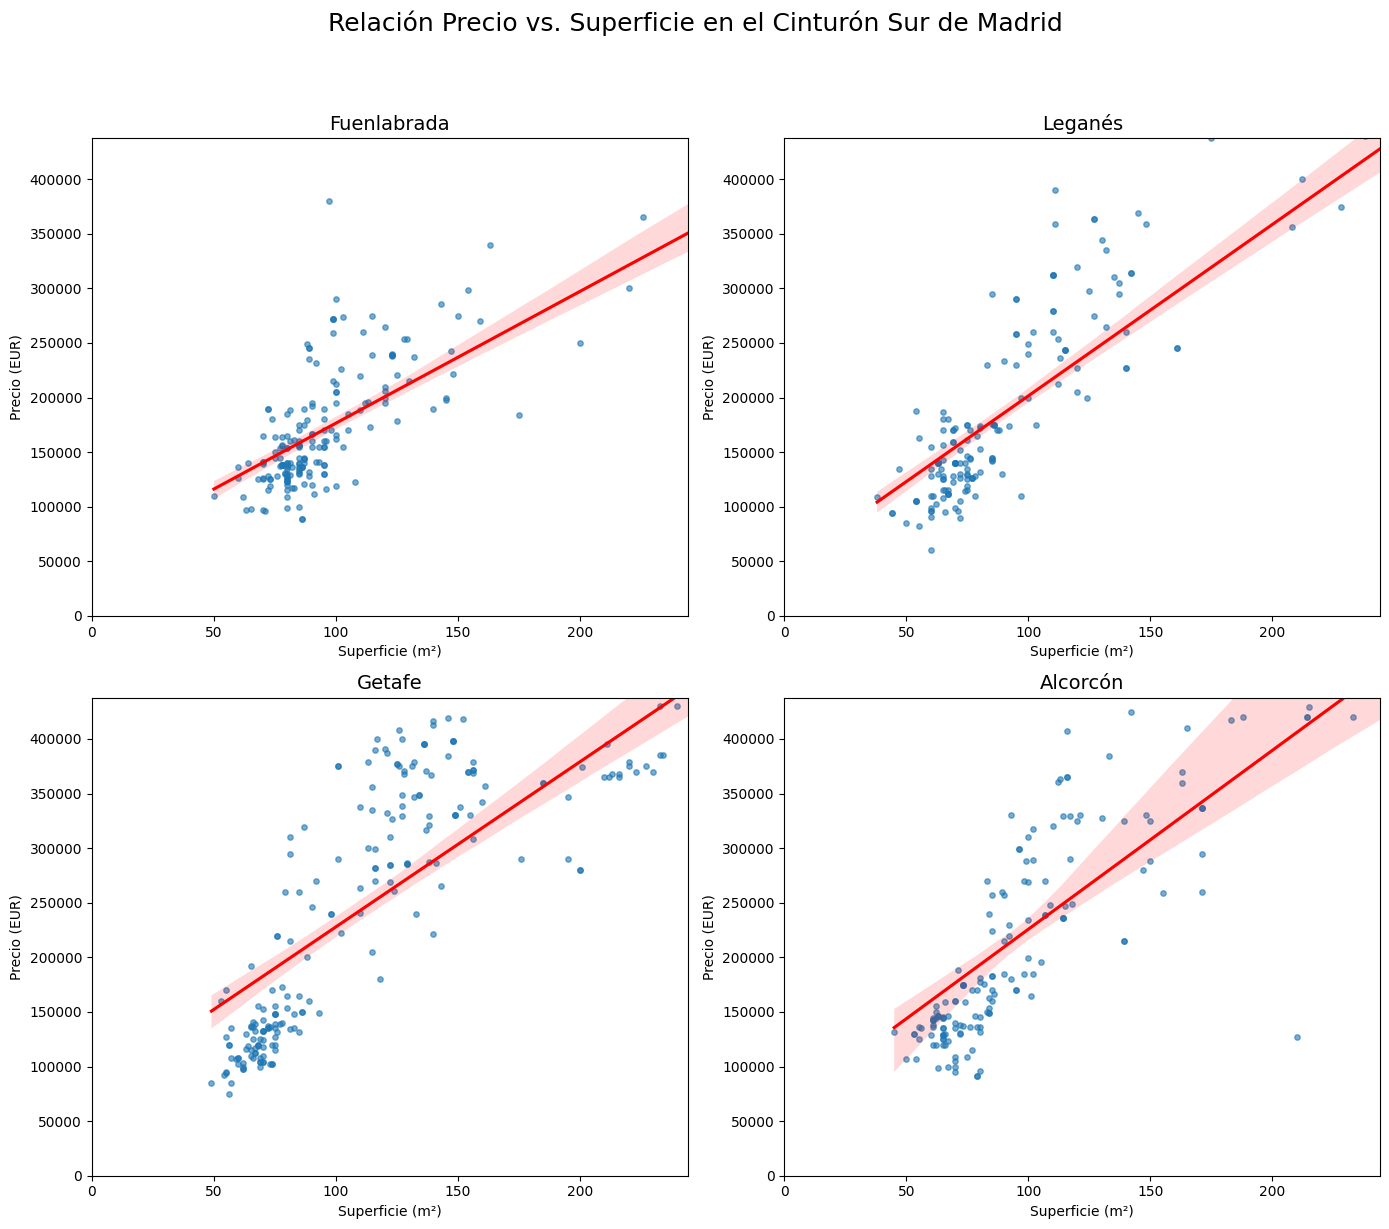

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

FILE_PATH = 'real_estate.csv'
POBLACIONES = ["Fuenlabrada", "Leganés", "Getafe", "Alcorcón"]

# 1. CARGAR Y PREPARAR DATOS (Recreando el subset del E14 por seguridad)
df = pd.read_csv('assets/real_estate.csv', sep=';')

# Convertir a numérico y crear el subconjunto
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['surface'] = pd.to_numeric(df['surface'], errors='coerce')
df_cinturon_sur = df[df['level5'].isin(POBLACIONES)].copy()

# Limpiar outliers y NaNs para la visualización
df_clean = df_cinturon_sur.dropna(subset=['price', 'surface'])
df_clean = df_clean[(df_clean['price'] > 1000) & (df_clean['surface'] > 10)]

# 2. DEFINIR LÍMITES COMUNES PARA EL ZOOM
# Usamos un límite común para que la comparación visual sea justa (ej. el percentil 95 de la superficie total)
max_surface_limit = df_clean['surface'].quantile(0.95)
max_price_limit = df_clean['price'].quantile(0.95)


# 3. CREAR Y TRAZAR LOS SUBGRÁFICOS
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten() # Aplanar para poder iterar fácilmente

fig.suptitle('Relación Precio vs. Superficie en el Cinturón Sur de Madrid', fontsize=18, y=1.02)

for i, poblacion in enumerate(POBLACIONES):
    # Filtrar datos de la población actual
    data_poblacion = df_clean[df_clean['level5'] == poblacion]
    
    # Trazar el scatter plot con línea de regresión (regplot)
    sns.regplot(x='surface', y='price', data=data_poblacion, 
                scatter_kws={'alpha':0.6, 's':15}, 
                line_kws={'color':'red'},
                ax=axes[i])
    
    # Configurar subgráfico
    axes[i].set_title(poblacion, fontsize=14)
    axes[i].set_xlabel('Superficie (m²)')
    axes[i].set_ylabel('Precio (EUR)')
    
    # Aplicar límites para asegurar una visualización clara y comparable
    axes[i].set_xlim(0, max_surface_limit)
    axes[i].set_ylim(0, max_price_limit)
    axes[i].ticklabel_format(style='plain', axis='y') # Quitar notación científica en Y

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Ajustar diseño
plt.show()

1. Correlación Positiva Universal
En los cuatro municipios, se confirma una fuerte correlación positiva entre la superficie y el precio. La línea roja de regresión en todos los gráficos asciende de izquierda a derecha. Esto significa que, sin excepción, el tamaño de la propiedad es el principal motor del precio en todo el Cinturón Sur.

2. Diferencias en el Valor Marginal (Pendiente)
Aunque todos son positivos, se aprecian diferencias sutiles en la pendiente de la línea:

Getafe y Alcorcón: La línea de regresión en estos municipios tiende a tener una pendiente más pronunciada (más inclinada). Esto significa que el precio aumenta más rápidamente por cada metro cuadrado adicional que se compra. Esta observación refuerza el hallazgo del Ejercicio 19: Getafe y Alcorcón tienen un Precio/m² superior, por lo que cada metro cuadrado extra contribuye más al precio final.

Fuenlabrada y Leganés: La línea de regresión es más suave. El precio sube con la superficie, pero el retorno en valor por cada metro cuadrado adicional es menor en comparación con Getafe y Alcorcón.

3. Dispersión y Variabilidad
Alcorcón y Getafe muestran una mayor dispersión vertical de puntos, especialmente en los segmentos de precio más altos. Esto indica que en estas ciudades, el precio final de las propiedades grandes es menos predecible, ya que factores no incluidos en el gráfico (lujo, ubicación específica del barrio) tienen un mayor peso.

Fuenlabrada y Leganés tienen puntos más agrupados alrededor de la línea, lo que sugiere una relación Precio-Superficie más lineal y predecible.

#### Ejercicio 21. Realiza un trazado de las coordenadas (columnas latitud y longitud) del cinturón sur de Madrid por color de cada población (debes usar el subconjunto obtenido del Ejercicio 14) (★★★★)

Ejecuta la siguiente celda y luego comienza a codear en la siguiente. Debes implementar un código simple que transforme las columnas de coordenadas en un diccionario de Python (agrega más información si es necesario) y agrégala al mapa.

In [61]:
!pip install folium


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Rango de coordenadas:
Latitud: 0.0000 a 0.0000
Longitud: 0.0000 a 0.0000


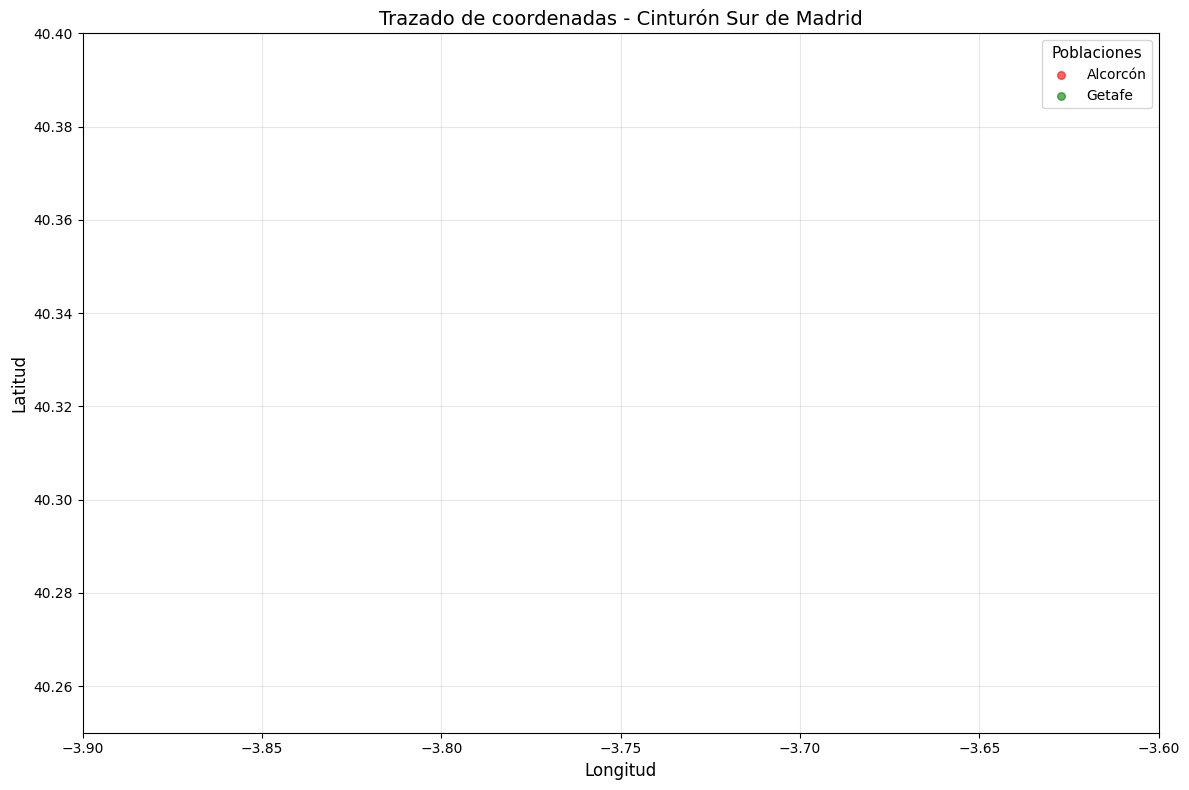


Resumen del diccionario creado:
Alcorcón: 1 coordenadas
Getafe: 10 coordenadas


In [66]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar y preparar datos
df = pd.read_csv('assets/real_estate.csv', sep=';')

# Convertir coordenadas correctamente
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

POBLACIONES = ["Fuenlabrada", "Leganés", "Getafe", "Alcorcón"]
df_cinturon_sur = df[df['level5'].isin(POBLACIONES)].copy()
df_cinturon_sur.dropna(subset=['latitude', 'longitude'], inplace=True)

# Verificar el rango de coordenadas
print("Rango de coordenadas:")
print(f"Latitud: {df_cinturon_sur['latitude'].min():.4f} a {df_cinturon_sur['latitude'].max():.4f}")
print(f"Longitud: {df_cinturon_sur['longitude'].min():.4f} a {df_cinturon_sur['longitude'].max():.4f}")

# Transformar a diccionario como pide el ejercicio
coord_dict_por_poblacion = (
    df_cinturon_sur
    .groupby('level5')[['latitude', 'longitude']]
    .apply(lambda x: x.to_dict('records'))
    .to_dict()
)

# Crear el gráfico corregido
plt.figure(figsize=(12, 8))

colores = {
    "Fuenlabrada": "blue",
    "Leganés": "orange", 
    "Getafe": "green",
    "Alcorcón": "red"
}

# Trazar usando el diccionario
for poblacion, coordenadas in coord_dict_por_poblacion.items():
    latitudes = [coord['latitude'] for coord in coordenadas]
    longitudes = [coord['longitude'] for coord in coordenadas]
    
    plt.scatter(longitudes, latitudes, 
                c=colores[poblacion], 
                label=poblacion, 
                alpha=0.6, 
                s=30)

# Configuración correcta del gráfico
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.title('Trazado de coordenadas - Cinturón Sur de Madrid', fontsize=14)
plt.legend(title='Poblaciones', title_fontsize=11)
plt.grid(True, alpha=0.3)

# Ajustar los límites del gráfico para Madrid
plt.xlim(-3.9, -3.6)   # Longitud aproximada de Madrid
plt.ylim(40.25, 40.40) # Latitud aproximada de Madrid

plt.tight_layout()
plt.show()

# Mostrar estadísticas del diccionario
print("\nResumen del diccionario creado:")
for poblacion, coords in coord_dict_por_poblacion.items():
    print(f"{poblacion}: {len(coords)} coordenadas")

In [ ]:
## Aquí: traza la coordenadas de los estados

## PON TU CÓDIGO AQUÍ:
